In [12]:
import yfinance as yf
import pandas as pd
import os

In [13]:
if os.path.exists('sp500.csv'):
    sp500 = pd.read_csv('sp500.csv', index_col = 0)
else:
    sp500 = yf.Ticker('^GSPC')
    sp500 = sp500.history(period='max')
    sp500.to_csv('sp500.csv')

In [14]:
sp500.index = pd.to_datetime(sp500.index)


In [15]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-06-10 00:00:00-04:00,7350.540039,7396.560059,7265.930176,7266.990234,5247300000,0.0,0.0
2026-06-11 00:00:00-04:00,7287.669922,7412.680176,7257.330078,7394.299805,5658920000,0.0,0.0
2026-06-12 00:00:00-04:00,7410.850098,7456.399902,7363.009766,7431.459961,4950530000,0.0,0.0


<Axes: xlabel='Date'>

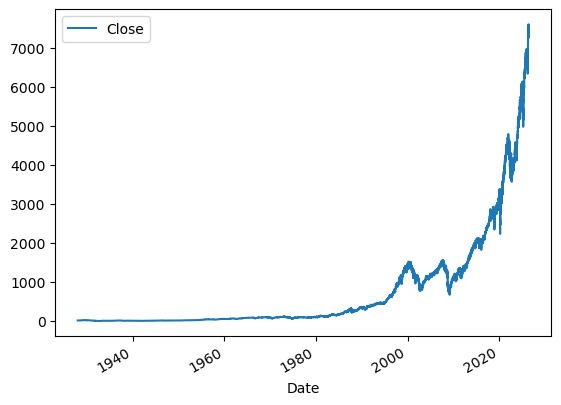

In [19]:
sp500.plot.line(y='Close', use_index = True)

In [21]:
del sp500['Dividends']
del sp500['Stock Splits']


In [22]:
sp500

,Open,High,Low,Close,Volume
Date,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
...,...,...,...,...,...
2026-06-10 00:00:00-04:00,7350.540039,7396.560059,7265.930176,7266.990234,5247300000
2026-06-11 00:00:00-04:00,7287.669922,7412.680176,7257.330078,7394.299805,5658920000
2026-06-12 00:00:00-04:00,7410.850098,7456.399902,7363.009766,7431.459961,4950530000


In [23]:
sp500['Tomorrow'] = sp500['Close'].shift(-1)

In [24]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-06-10 00:00:00-04:00,7350.540039,7396.560059,7265.930176,7266.990234,5247300000,7394.299805
2026-06-11 00:00:00-04:00,7287.669922,7412.680176,7257.330078,7394.299805,5658920000,7431.459961
2026-06-12 00:00:00-04:00,7410.850098,7456.399902,7363.009766,7431.459961,4950530000,7554.290039


In [25]:
sp500['Target'] = (sp500['Tomorrow'] > sp500['Close']).astype(int)

In [26]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-06-10 00:00:00-04:00,7350.540039,7396.560059,7265.930176,7266.990234,5247300000,7394.299805,1
2026-06-11 00:00:00-04:00,7287.669922,7412.680176,7257.330078,7394.299805,5658920000,7431.459961,1
2026-06-12 00:00:00-04:00,7410.850098,7456.399902,7363.009766,7431.459961,4950530000,7554.290039,1


In [27]:
sp500 = sp500.loc['1990-01-01':].copy()

In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state = 1)

train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ['Close', 'Volume', 'Open', 'High', 'Low']

model.fit(train[predictors], train['Target'])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [33]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])
preds = pd.Series(preds, index = test.index)
precision_score(test['Target'], preds)

In [34]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
precision_score(test["Target"], preds)

0.5555555555555556

<Axes: xlabel='Date'>

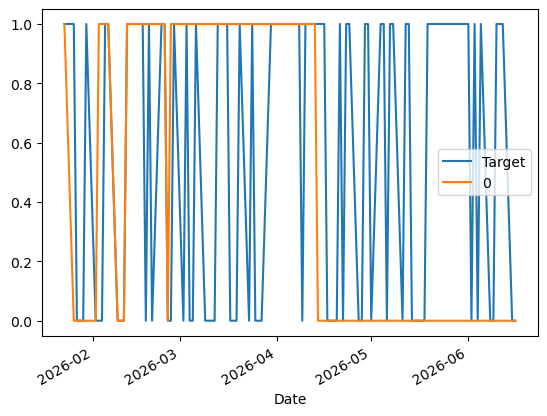

In [35]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()

In [36]:
def predict(train,test,predictors,model):
    model.fit(train[predictors], train['Target'])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name='Predictions')
    combined = pd.concat([test['Target'], preds], axis=1)
    return combined

In [37]:
def backtest(data, model, predictors, start=2500, step = 250):
    all_predictions = []

    for i in range(start,data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [38]:
predictions = backtest(sp500, model, predictors)


In [39]:
predictions['Predictions'].value_counts()

Predictions
0    3995
1    2686
Name: count, dtype: int64

In [40]:
precision_score(predictions['Target'], predictions['Predictions'])

0.5312732688011914

In [41]:
predictions['Target'].value_counts() / predictions.shape[0]

Target
1    0.537943
0    0.462057
Name: count, dtype: float64

In [43]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean()

    ratio_column = f'Close_Ratio_{horizon}'
    sp500[ratio_column] = sp500['Close'] / rolling_averages['Close']

    trend_column = f'Trend_{horizon}'
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()['Target']

    new_predictors+= [ratio_column, trend_column]

In [44]:
sp500 = sp500.dropna(subset=sp500.columns[sp500.columns != 'Tomorrow'])

In [45]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-10 00:00:00-04:00,7350.540039,7396.560059,7265.930176,7266.990234,5247300000,7394.299805,1,0.991834,0.0,0.981298,2.0,1.023423,37.0,1.076300,143.0,1.370543,545.0
2026-06-11 00:00:00-04:00,7287.669922,7412.680176,7257.330078,7394.299805,5658920000,7431.459961,1,1.008683,1.0,1.003640,2.0,1.039697,37.0,1.094281,143.0,1.393606,545.0
2026-06-12 00:00:00-04:00,7410.850098,7456.399902,7363.009766,7431.459961,4950530000,7554.290039,1,1.002506,2.0,1.007379,3.0,1.042950,38.0,1.098835,144.0,1.399616,546.0


In [46]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [47]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train['Target'])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >=.6] = 1
    preds[preds <.6] = 0
    preds = pd.Series(preds, index = test.index, name='Predictions')
    combined = pd.concat([test['Target'], preds], axis = 1)
    return combined

In [48]:
predictions = backtest(sp500, model, new_predictors)

In [49]:
predictions['Predictions'].value_counts()

Predictions
0.0    4803
1.0     878
Name: count, dtype: int64

In [50]:
precision_score(predictions['Target'], predictions['Predictions'])


0.5763097949886105

In [51]:
predictions['Target'].value_counts() / predictions.shape[0]

Target
1    0.547263
0    0.452737
Name: count, dtype: float64

In [52]:
predictions

,Target,Predictions
Date,,
2003-11-14 00:00:00-05:00,0,0.0
2003-11-17 00:00:00-05:00,0,1.0
2003-11-18 00:00:00-05:00,1,1.0
2003-11-19 00:00:00-05:00,0,0.0
2003-11-20 00:00:00-05:00,1,1.0
...,...,...
2026-06-10 00:00:00-04:00,1,0.0
2026-06-11 00:00:00-04:00,1,0.0
2026-06-12 00:00:00-04:00,1,0.0
